## **Work Environment**

Open data folder. Right click on folder > Organize > Add shortcut > My Drive

https://drive.google.com/drive/folders/1yaqFlitgmkzlcda1hQJfKPFs0m_u3sTZ?usp=sharing

In [12]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [2]:
# Check that path exists
import os
os.path.exists("/content/drive/MyDrive/VisCap")

True

In [3]:
cd /content/drive/MyDrive/VisCap

/content/drive/.shortcut-targets-by-id/1yaqFlitgmkzlcda1hQJfKPFs0m_u3sTZ/VisCap


## 1 — Setup

In [5]:
import torch, json
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from torchvision import transforms

from models.text_encoder import Tokenizer
from models.model        import MultimodalModel

# Load checkpoint
ckpt = torch.load('exp/best.pt', map_location='cpu')
cfg  = ckpt['cfg']

# Tokenizer
tok = Tokenizer(cfg['vocab_size'], cfg['max_seq_len'])
tok.load('exp/vocab.json')
cfg['vocab_size'] = len(tok)

# Model
model = MultimodalModel(cfg)
model.load_state_dict(ckpt['model'])
model.eval()

# Normalisation stats computed from the actual training data
stats = json.load(open('exp/norm_stats.json'))
mean, std = stats['mean'], stats['std']

# Dataset metadata
cat_names = json.load(open('data/categories.json'))   # 80 COCO class names
ann_val   = json.load(open('data/val/annotations.json'))

# Image preprocessor
tfm = transforms.Compose([
    transforms.Resize((cfg['image_size'], cfg['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
def preprocess(img): return tfm(img.convert('RGB')).unsqueeze(0)

print(f'Checkpoint : epoch {ckpt["epoch"]}')
print(f'Parameters : {sum(p.numel() for p in model.parameters()):,}')
print(f'Val samples: {len(ann_val)}')
print(f'Norm mean  : {[round(v,4) for v in mean]}')
print(f'Norm std   : {[round(v,4) for v in std]}')

Checkpoint : epoch 15
Parameters : 2,071,681
Val samples: 991
Norm mean  : [0.4695, 0.4466, 0.4074]
Norm std   : [0.2267, 0.2219, 0.226]


## 2 — Training Curves

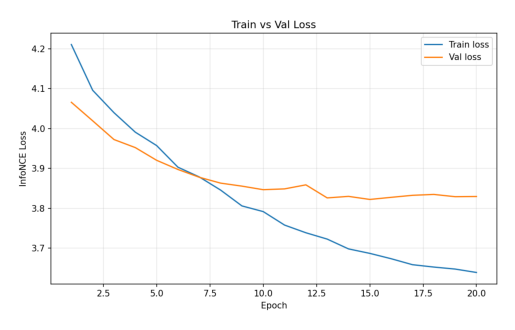

In [7]:
# Display Training Curves
from PIL import Image
import matplotlib.pyplot as plt

path = "exp/loss_curve.png"
img = Image.open(path)

plt.imshow(img)
plt.axis("off")
plt.show()

## 3. Zero-Shot Classification

426297


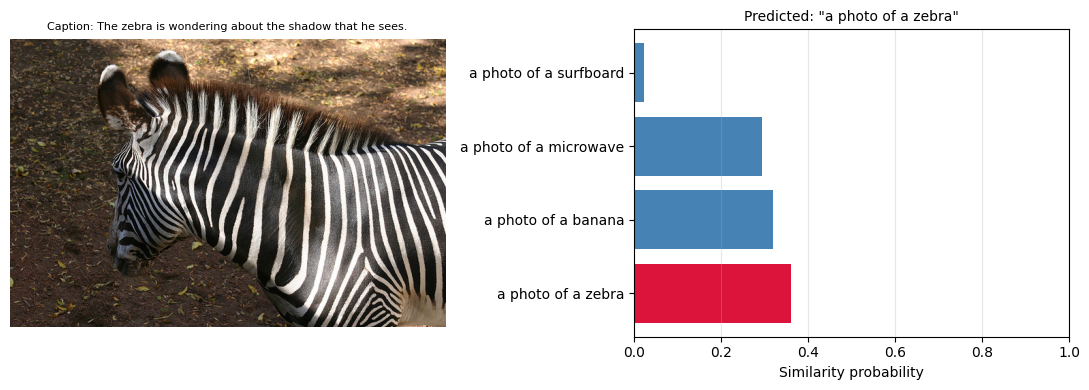

In [20]:
# Single image — GT classes as prompts plus a few distractors
sample = ann_val[200]
img    = Image.open(Path('data') / sample['file_path'])

gt_ids  = list({lbl for lbl in sample['labels'][:5]})
prompts = [f'a photo of a {cat_names[i]}' for i in gt_ids]
prompts += ['a photo of a banana', 'a photo of a microwave', 'a photo of a surfboard']

with torch.no_grad():
    probs = model.zero_shot(preprocess(img), tok.encode(prompts))

best   = probs.argmax().item()
colors = ['crimson' if i == best else 'steelblue' for i in range(len(prompts))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.imshow(img)
ax1.axis('off')
ax1.set_title(f'Caption: {sample["caption"][:70]}', fontsize=8)
ax2.barh(prompts, probs.tolist(), color=colors)
ax2.set_xlim(0, 1)
ax2.set_xlabel('Similarity probability')
ax2.set_title(f'Predicted: "{prompts[best]}"', fontsize=10)
ax2.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 4 — Inference from the command line

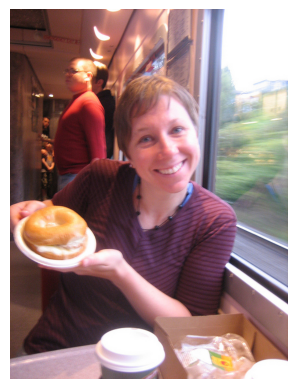

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(

Results:
  0.4839  a photo of a person
  0.3044  a photo of a refrigerator
  0.2117  a photo of a train

Predicted: a photo of a person


In [4]:
# Display image
from PIL import Image
import matplotlib.pyplot as plt

path = "data/Images/000000038678.jpg"
img = Image.open(path)

plt.imshow(img)
plt.axis("off")
plt.show()

# Run inference
!python inference.py --image data/Images/000000038678.jpg --prompts "a photo of a train" "a photo of a person" "a photo of a refrigerator"

## 3 — Cosine Similarity Matrix

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


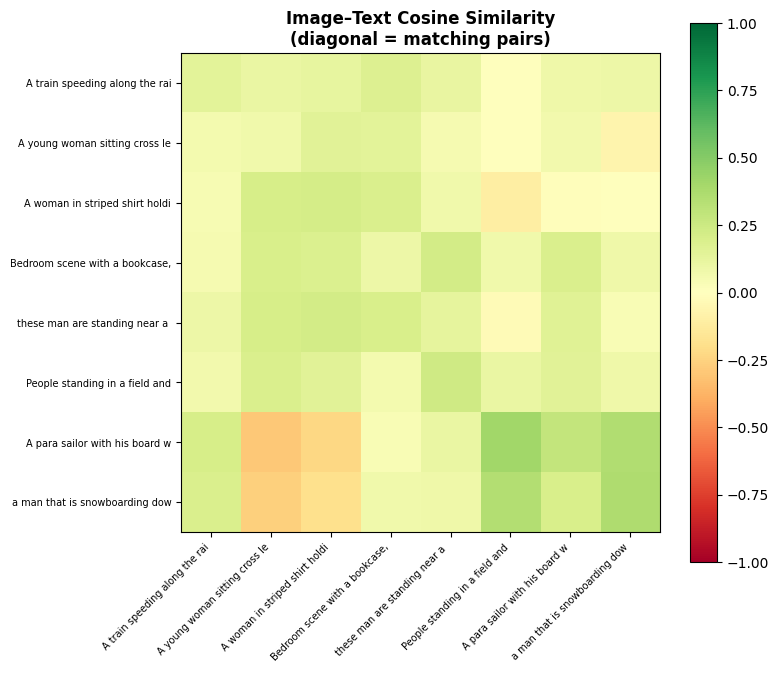

Mean diagonal (matching)     : 0.175
Mean off-diagonal (non-match): 0.095
Gap (higher = better)        : 0.080


In [6]:
# How well do image and text embeddings align?
# Diagonal = matching pairs — should be the highest in each row/column.
n      = 8
batch  = ann_val[:n]
images = torch.cat([preprocess(Image.open(Path('data') / s['file_path'])) for s in batch])
caps   = [s['caption'] for s in batch]

with torch.no_grad():
    img_emb = model.encode_image(images)
    txt_emb = model.encode_text(tok.encode(caps))
    sim     = (img_emb @ txt_emb.T).numpy()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(sim, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(n))
ax.set_xticklabels([c[:30] for c in caps], rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(n))
ax.set_yticklabels([c[:30] for c in caps], fontsize=7)
ax.set_title('Image–Text Cosine Similarity\n(diagonal = matching pairs)', fontweight='bold')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

diag    = sim.diagonal().mean()
offdiag = (sim.sum() - sim.diagonal().sum()) / (n * n - n)
print(f'Mean diagonal (matching)     : {diag:.3f}')
print(f'Mean off-diagonal (non-match): {offdiag:.3f}')
print(f'Gap (higher = better)        : {diag - offdiag:.3f}')